In [2]:
import os
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import numpy as np
import sys
import subprocess
from pathlib import Path
from dotenv import load_dotenv
load_dotenv()
PROJECT_ROOT = os.environ.get("PROJECT_ROOT")
PYTHON_IO_ENCODING = os.environ.get("PYTHON_IO_ENCODING")


Original: dtype=uint8, range=[0, 255]
Normalized: dtype=float32, range=[0.000, 1.000]


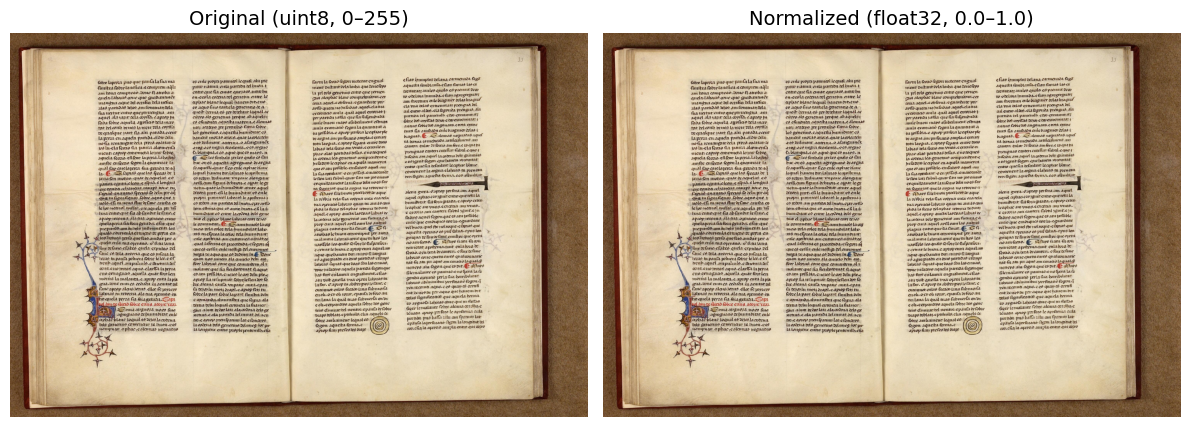

In [6]:
input_path = os.path.join(PROJECT_ROOT, "data", "raw", "original_manuscript", "reproduction14453_100", "37 - f. 032v - 033.jpg")
img = Image.open(input_path)
img_np = np.array(img)  # uint8, [0, 255]
img_01 = img_np.astype(np.float32) / 255.0  # float32, [0.0, 1.0]

print(f"Original: dtype={img_np.dtype}, range=[{img_np.min()}, {img_np.max()}]")
print(f"Normalized: dtype={img_01.dtype}, range=[{img_01.min():.3f}, {img_01.max():.3f}]")

# === Plotting ===
plt.figure(figsize=(12, 6))

# Original image (uint8)
plt.subplot(1, 2, 1)
plt.imshow(img_np, cmap='gray' if img_np.ndim == 2 else None)  # auto grayscale if needed
plt.title("Original (uint8, 0–255)", fontsize=14)
plt.axis('off')

# Normalized image (float32 [0,1])
plt.subplot(1, 2, 2)
# ⚠️ matplotlib expects float images in [0,1] → perfect for img_01!
plt.imshow(img_01, cmap='gray' if img_01.ndim == 2 else None)
plt.title("Normalized (float32, 0.0–1.0)", fontsize=14)
plt.axis('off')

plt.tight_layout()
plt.show()

In [8]:
import os
import numpy as np
from PIL import Image
from tqdm import tqdm

def calculate_dataset_stats(image_dir, extensions=('.jpg', '.jpeg', '.png', '.tiff', '.tif')):
    # 1. Collect all valid image paths
    valid_ext = tuple(e.lower() for e in extensions)
    image_paths = [
        os.path.join(root, f) 
        for root, _, files in os.walk(image_dir) 
        for f in files 
        if f.lower().endswith(valid_ext)
    ]
    print(f"Found {len(image_paths)} images.")
    
    # 2. First pass: Calculate Mean
    channel_sum = np.zeros(3)
    pixel_count = 0
    
    for path in tqdm(image_paths, desc="📊 Calculating Mean"):
        img = Image.open(path).convert('RGB')  # Forces 3 channels even if grayscale
        img_np = np.array(img).astype(np.float32) / 255.0
        channel_sum += np.sum(img_np, axis=(0, 1))
        pixel_count += img_np.shape[0] * img_np.shape[1]
        
    mean = channel_sum / pixel_count
    print(f"✅ Dataset Mean (RGB): {mean}")
    
    # 3. Second pass: Calculate Std
    channel_sq_diff_sum = np.zeros(3)
    
    for path in tqdm(image_paths, desc="📉 Calculating Std"):
        img = Image.open(path).convert('RGB')
        img_np = np.array(img).astype(np.float32) / 255.0
        diff = img_np - mean
        channel_sq_diff_sum += np.sum(diff**2, axis=(0, 1))
        
    std = np.sqrt(channel_sq_diff_sum / pixel_count)
    print(f"✅ Dataset Std (RGB):  {std}")
    
    return mean.tolist(), std.tolist()

# === RUN IT ===
# Replace with your actual dataset root directory
DATASET_DIR = os.path.join(PROJECT_ROOT, "data", "raw", "original_manuscript", "reproduction14453_100")
mean, std = calculate_dataset_stats(DATASET_DIR)

print("\n📋 COPY-PASTE THESE INTO YOUR PIPELINE:")
print(f"mean = {mean}")
print(f"std  = {std}")

Found 71 images.


📊 Calculating Mean: 100%|██████████| 71/71 [00:04<00:00, 15.84it/s]


✅ Dataset Mean (RGB): [0.75336459 0.63800125 0.54252563]


📉 Calculating Std: 100%|██████████| 71/71 [00:08<00:00,  8.64it/s]

✅ Dataset Std (RGB):  [0.24612456 0.26474225 0.25268567]

📋 COPY-PASTE THESE INTO YOUR PIPELINE:
mean = [0.7533645887018015, 0.6380012466612541, 0.5425256345088072]
std  = [0.24612455882239695, 0.26474224681036995, 0.252685666231032]


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.0609078277532964..1.8104484212132606].


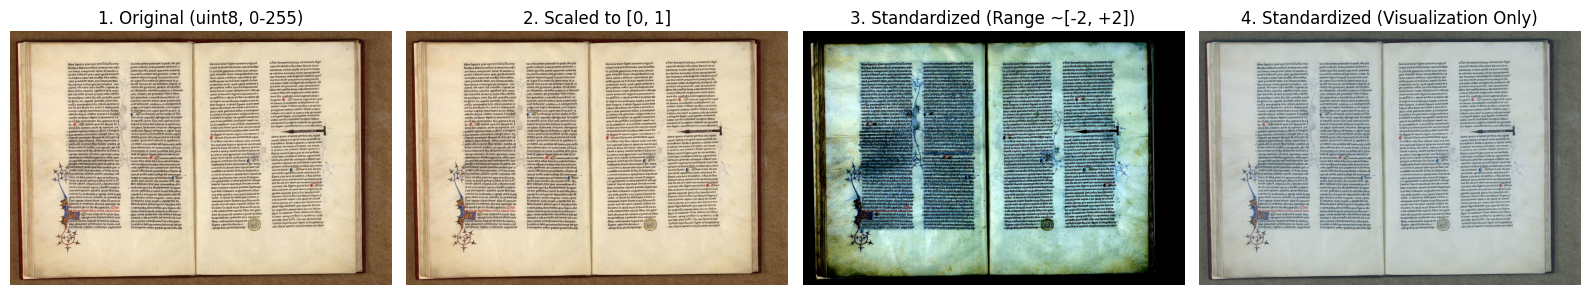

In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# === 1. Load and Scale [0, 1] (Your existing code) ===
# (Assuming input_path and PROJECT_ROOT are defined)
img = Image.open(input_path).convert('RGB') # Ensure RGB just in case
img_np = np.array(img)
img_01 = img_np.astype(np.float32) / 255.0

# === 2. Standardization (Mean/Std) ===
# Using ImageNet stats as a default example
mean_ = mean#np.array([0.485, 0.456, 0.406])
std_  = std#np.array([0.229, 0.224, 0.225])

# Apply: (x - mean) / std
# We reshape mean/std to (1, 1, 3) to match the image shape (H, W, C)
img_std = (img_01 - mean) / std

# === 3. Plotting ===
plt.figure(figsize=(16, 4))

# Image 1: Original (uint8)
plt.subplot(1, 4, 1)
plt.imshow(img_np)
plt.title("1. Original (uint8, 0-255)", fontsize=12)
plt.axis('off')

# Image 2: Scaled [0,1] (float32)
plt.subplot(1, 4, 2)
plt.imshow(img_01)
plt.title("2. Scaled to [0, 1]", fontsize=12)
plt.axis('off')

# Image 3: Standardized (Clipped View)
# ⚠️ This looks weird because imshow expects [0,1].
# Values < 0 become black, values > 1 become white.
plt.subplot(1, 4, 3)
plt.imshow(img_std, vmin=-1, vmax=1) # Expanded range to see data
plt.title("3. Standardized (Range ~[-2, +2])", fontsize=12)
plt.axis('off')

# Image 4: Standardized (Rescaled just for visualization)
# We temporarily stretch it back to [0,1] ONLY to see the texture.
# This is NOT for the model, just for your eyes.
img_std_vis = (img_std - img_std.min()) / (img_std.max() - img_std.min())
#img_recovered = (img_std * std) + mean
plt.subplot(1, 4, 4)
plt.imshow(img_std_vis)
plt.title("4. Standardized (Visualization Only)", fontsize=12)
plt.axis('off')

plt.tight_layout()
plt.show()

## Using PyTorch

In [12]:
from torchvision import transforms
from PIL import Image

img = Image.open(input_path)

# ToTensor() handles: uint8→float32, /255.0, HWC→CHW
img_tensor = transforms.ToTensor()(img)

print(img_tensor.shape, img_tensor.min().item(), img_tensor.max().item())
# e.g., torch.Size([3, 256, 256]) 0.0 1.0

torch.Size([3, 1995, 3000]) 0.0 1.0
